In [65]:
# import libraries
import gzip
import os
import json
import csv
import pandas as pd 
import numpy as np

In [66]:
pip install jsonlines

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [67]:
import jsonlines

In [68]:
def extract(gz_path, csv_path):
    if not os.path.exists(gz_path):
        raise FileNotFoundError(f"File Not Found: {gz_path}")
    if not gz_path.endswith(".gz"):
        raise ValueError("Input file must be a .gz file")
    success_count= 0 
    error_count= 0 
    header= None
    try:
        with gzip.open(gz_path, mode="rt", encoding="utf-8") as gz_file, \
             open(csv_path, mode="w", newline="", encoding="utf-8") as csv_file:
            writer= csv.writer(csv_file)

            for line_number, line in enumerate(gz_file, start=1):
                try: 
                    record= json.loads(line)
                    if header is None: 
                        header = list(record.keys())
                        writer.writerow(header)
                    row= [record.get(col,None) for col in header]
                    writer.writerow(row)
                    success_count+=1 

                except json.JSONDecodeError: 
                    error_count +=1 
                    continue 
    except OSError as e: 
        raise OSError(f"Gzip file error: {e}")
    print("Finished Processing")
    # track success 
    print(f"Successful records: {success_count}")
    # log failures 
    print(f"Failed records: {error_count}")

In [69]:
extract( "Amazon_Fashion.jsonl (2).gz",
    "review.csv")

Finished Processing
Successful records: 2500939
Failed records: 0


In [70]:
import gzip
import json

def inspect_raw_price(gz_path, n=100):
    count_has_price = 0
    samples = []

    with gzip.open(gz_path, "rt", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= n:
                break
            try:
                record = json.loads(line)
                if "price" in record:
                    count_has_price += 1
                    samples.append(record["price"])
            except json.JSONDecodeError:
                continue

    print(f"Out of {n} records:")
    print(f"Records with 'price' key: {count_has_price}")
    print("Sample price values:")
    for s in samples[:10]:
        print(s)


In [71]:
inspect_raw_price("Amazon_Fashion.jsonl (2).gz")

Out of 100 records:
Records with 'price' key: 0
Sample price values:


In [72]:
inspect_raw_price("meta_Amazon_Fashion.jsonl (1).gz")

Out of 100 records:
Records with 'price' key: 100
Sample price values:
None
None
None
29.81
17.99
None
None
None
9.99
None


In [73]:
extract(
    "meta_Amazon_Fashion.jsonl (1).gz",
    "product.csv"
)

Finished Processing
Successful records: 826108
Failed records: 0


In [74]:
# extract only the first 100K rows 
product_data= pd.read_csv('product.csv')
review_data= pd.read_csv('review.csv')

In [75]:
product_data.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,AMAZON FASHION,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],GiveGift,[],{'Package Dimensions': '10.31 x 8.5 x 1.73 inc...,B08BHN9PK5,NaN
1,AMAZON FASHION,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"['Drawstring closure', 'Machine Wash']",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],DouBCQ,[],{'Package Dimensions': '15 x 10.2 x 0.4 inches...,B08R39MRDW,NaN
2,AMAZON FASHION,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"['Zipper closure', 'Hand Wash Only']",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Pastel by Vivienne,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B077KJHCJ4,NaN
3,AMAZON FASHION,Mento Streamtail,2.0,1,"['Thermoplastic Rubber sole', 'High Density Pr...","[""Slip on the Women's Mento and you're ready t...",29.81,[{'thumb': 'https://m.media-amazon.com/images/...,[],Guy Harvey,[],{'Package Dimensions': '11.22 x 4.72 x 4.33 in...,B0811M2JG9,NaN
4,AMAZON FASHION,RONNOX Women's 3-Pairs Bright Colored Calf Com...,4.3,3032,"['Pull On closure', 'Size Guide: ""S"" fits calf...",['Ronnox Calf Sleeves - Allowing Your Body to ...,17.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': ""HONEST Review: RONNOX Women's 3-Pa...",RONNOX,[],"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B07SB2892S,NaN


In [76]:
review_data.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Pretty locket,I think this locket is really pretty. The insi...,[],B00LOPVX74,B00LOPVX74,AGBFYI2DDIKXC5Y4FARTYDTQBMFQ,1578528394489,3,True
1,5.0,A,Great,[],B07B4JXK8D,B07B4JXK8D,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,1608426246701,0,True
2,2.0,Two Stars,One of the stones fell out within the first 2 ...,[],B007ZSEQ4Q,B007ZSEQ4Q,AHITBJSS7KYUBVZPX7M2WJCOIVKQ,1432344828000,3,True
3,1.0,Won’t buy again,Crappy socks. Money wasted. Bought to wear wit...,[],B07F2BTFS9,B07F2BTFS9,AFVNEEPDEIH5SPUN5BWC6NKL3WNQ,1546289847095,2,True
4,5.0,I LOVE these glasses,I LOVE these glasses! They fit perfectly over...,[],B00PKRFU4O,B00XESJTDE,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,1439476166000,0,True


In [77]:
# merge 
df= pd.merge(product_data, review_data, on='parent_asin', how='inner')

In [78]:
df.head()

,main_category,title_x,average_rating,rating_number,features,description,price,images_x,videos,store,...,bought_together,rating,title_y,text,images_y,asin,user_id,timestamp,helpful_vote,verified_purchase
0,AMAZON FASHION,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],GiveGift,...,NaN,5.0,Great sock!,"This sock fits great, holds it shape and is ve...",[],B08BHN9PK5,AFHJMTD3GAMEH722HTM2VEXNOM5Q,1606007321259,0,True
1,AMAZON FASHION,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"['Drawstring closure', 'Machine Wash']",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],DouBCQ,...,NaN,4.0,Fit okay,Since my legs and stomach are my larger areas ...,[],B08R39MRDW,AH4MZTCIOZHWELLOMO5AV5J2CFUA,1619271363761,1,False
2,AMAZON FASHION,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"['Drawstring closure', 'Machine Wash']",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],DouBCQ,...,NaN,5.0,fits great and has a silky feel against the skin,These pants fit very well and felt extremely c...,[],B08R39MRDW,AFKXMG5RTMVMZXBG75SNK5PCMI3A,1631926389500,0,True
3,AMAZON FASHION,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"['Zipper closure', 'Hand Wash Only']",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Pastel by Vivienne,...,NaN,5.0,Perfect causal dress,We bought this dress for our daughter to wear ...,[],B077KJHCJ4,AE4RDNNXG3FCUDJZ2PAVSGJRFRGQ,1577068622955,0,True
4,AMAZON FASHION,Mento Streamtail,2.0,1,"['Thermoplastic Rubber sole', 'High Density Pr...","[""Slip on the Women's Mento and you're ready t...",29.81,[{'thumb': 'https://m.media-amazon.com/images/...,[],Guy Harvey,...,NaN,2.0,the size 9 may not be as true size,size is small,[],B0811M2JG9,AE2PFEWEGOFSFZATN6NGXOEHBEIA,1649042471529,0,False


In [79]:
df= df.rename(columns={'images_x': 'product_image','images_y':'review_image','title_x':'product_title', 'title_y':'review_title'
    
})

In [80]:
df.head()

,main_category,product_title,average_rating,rating_number,features,description,price,product_image,videos,store,...,bought_together,rating,review_title,text,review_image,asin,user_id,timestamp,helpful_vote,verified_purchase
0,AMAZON FASHION,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],GiveGift,...,NaN,5.0,Great sock!,"This sock fits great, holds it shape and is ve...",[],B08BHN9PK5,AFHJMTD3GAMEH722HTM2VEXNOM5Q,1606007321259,0,True
1,AMAZON FASHION,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"['Drawstring closure', 'Machine Wash']",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],DouBCQ,...,NaN,4.0,Fit okay,Since my legs and stomach are my larger areas ...,[],B08R39MRDW,AH4MZTCIOZHWELLOMO5AV5J2CFUA,1619271363761,1,False
2,AMAZON FASHION,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"['Drawstring closure', 'Machine Wash']",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],DouBCQ,...,NaN,5.0,fits great and has a silky feel against the skin,These pants fit very well and felt extremely c...,[],B08R39MRDW,AFKXMG5RTMVMZXBG75SNK5PCMI3A,1631926389500,0,True
3,AMAZON FASHION,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"['Zipper closure', 'Hand Wash Only']",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Pastel by Vivienne,...,NaN,5.0,Perfect causal dress,We bought this dress for our daughter to wear ...,[],B077KJHCJ4,AE4RDNNXG3FCUDJZ2PAVSGJRFRGQ,1577068622955,0,True
4,AMAZON FASHION,Mento Streamtail,2.0,1,"['Thermoplastic Rubber sole', 'High Density Pr...","[""Slip on the Women's Mento and you're ready t...",29.81,[{'thumb': 'https://m.media-amazon.com/images/...,[],Guy Harvey,...,NaN,2.0,the size 9 may not be as true size,size is small,[],B0811M2JG9,AE2PFEWEGOFSFZATN6NGXOEHBEIA,1649042471529,0,False


In [81]:
# drop main_category because it only has one value 
df= df.drop('main_category', axis= 1)

In [82]:
df['categories'].unique()

array(['[]'], dtype=object)

In [83]:
df= df.drop('categories', axis = 1)

In [84]:
df= df.drop('videos', axis= 1)

In [85]:
df['bought_together'].unique()

array([nan])

In [86]:
df= df.drop('bought_together', axis= 1)

In [87]:
df.head()

,product_title,average_rating,rating_number,features,description,price,product_image,store,details,parent_asin,rating,review_title,text,review_image,asin,user_id,timestamp,helpful_vote,verified_purchase
0,YUEDGE 5 Pairs Men's Moisture Control Cushione...,4.6,16,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,GiveGift,{'Package Dimensions': '10.31 x 8.5 x 1.73 inc...,B08BHN9PK5,5.0,Great sock!,"This sock fits great, holds it shape and is ve...",[],B08BHN9PK5,AFHJMTD3GAMEH722HTM2VEXNOM5Q,1606007321259,0,True
1,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"['Drawstring closure', 'Machine Wash']",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,DouBCQ,{'Package Dimensions': '15 x 10.2 x 0.4 inches...,B08R39MRDW,4.0,Fit okay,Since my legs and stomach are my larger areas ...,[],B08R39MRDW,AH4MZTCIOZHWELLOMO5AV5J2CFUA,1619271363761,1,False
2,DouBCQ Women's Palazzo Lounge Wide Leg Casual ...,4.1,7,"['Drawstring closure', 'Machine Wash']",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,DouBCQ,{'Package Dimensions': '15 x 10.2 x 0.4 inches...,B08R39MRDW,5.0,fits great and has a silky feel against the skin,These pants fit very well and felt extremely c...,[],B08R39MRDW,AFKXMG5RTMVMZXBG75SNK5PCMI3A,1631926389500,0,True
3,Pastel by Vivienne Honey Vanilla Girls' Trapez...,4.3,11,"['Zipper closure', 'Hand Wash Only']",[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,Pastel by Vivienne,"{'Is Discontinued By Manufacturer': 'No', 'Pac...",B077KJHCJ4,5.0,Perfect causal dress,We bought this dress for our daughter to wear ...,[],B077KJHCJ4,AE4RDNNXG3FCUDJZ2PAVSGJRFRGQ,1577068622955,0,True
4,Mento Streamtail,2.0,1,"['Thermoplastic Rubber sole', 'High Density Pr...","[""Slip on the Women's Mento and you're ready t...",29.81,[{'thumb': 'https://m.media-amazon.com/images/...,Guy Harvey,{'Package Dimensions': '11.22 x 4.72 x 4.33 in...,B0811M2JG9,2.0,the size 9 may not be as true size,size is small,[],B0811M2JG9,AE2PFEWEGOFSFZATN6NGXOEHBEIA,1649042471529,0,False


In [88]:
!pip install nltk


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [89]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'<[^>]+>', '', text)  # remove HTML tags
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text = re.sub(r'\d+', '', text)      # remove numbers
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]
    return ' '.join(tokens)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [90]:
# Làm sạch từng cột
for col in ['product_title', 'features', 'description', 'review_title', 'text','store','details']:
    df[col] = df[col].astype(str).apply(clean_text)

In [91]:
df.head()

,product_title,average_rating,rating_number,features,description,price,product_image,store,details,parent_asin,rating,review_title,text,review_image,asin,user_id,timestamp,helpful_vote,verified_purchase
0,yuedge pairs mens moisture control cushioned d...,4.6,16,,,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,givegift,package dimensions x x inches ounces item mode...,B08BHN9PK5,5.0,great sock,sock fits great holds shape comfortable,[],B08BHN9PK5,AFHJMTD3GAMEH722HTM2VEXNOM5Q,1606007321259,0,True
1,doubcq womens palazzo lounge wide leg casual f...,4.1,7,drawstring closure machine wash,,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,doubcq,package dimensions x x inches ounces item mode...,B08R39MRDW,4.0,fit okay,since legs stomach larger areas wish little ro...,[],B08R39MRDW,AH4MZTCIOZHWELLOMO5AV5J2CFUA,1619271363761,1,False
2,doubcq womens palazzo lounge wide leg casual f...,4.1,7,drawstring closure machine wash,,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,doubcq,package dimensions x x inches ounces item mode...,B08R39MRDW,5.0,fits great silky feel skin,pants fit well felt extremely comfortable happy,[],B08R39MRDW,AFKXMG5RTMVMZXBG75SNK5PCMI3A,1631926389500,0,True
3,pastel vivienne honey vanilla girls trapeze dr...,4.3,11,zipper closure hand wash,,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,pastel vivienne,discontinued manufacturer package dimensions x...,B077KJHCJ4,5.0,perfect causal dress,bought dress daughter wear family photos fit p...,[],B077KJHCJ4,AE4RDNNXG3FCUDJZ2PAVSGJRFRGQ,1577068622955,0,True
4,mento streamtail,2.0,1,thermoplastic rubber sole high density premium...,slip womens mento youre ready hit beach thong ...,29.81,[{'thumb': 'https://m.media-amazon.com/images/...,guy harvey,package dimensions x x inches pounds item mode...,B0811M2JG9,2.0,size may true size,size small,[],B0811M2JG9,AE2PFEWEGOFSFZATN6NGXOEHBEIA,1649042471529,0,False


In [92]:
def is_effectively_missing(x):
    # Case 1: NaN / None
    if pd.isna(x):
        return True

    # Case 2: empty or whitespace string
    if isinstance(x, str):
        x_strip = x.strip()
        if x_strip == "" or x_strip.lower() in ["none", "nan"]:
            return True

        # Case 3: string representation of empty list/dict
        if x_strip in ["[]", "{}"]:
            return True

    # Case 4: actual empty list / dict
    if isinstance(x, (list, dict)) and len(x) == 0:
        return True

    return False


In [93]:
effective_missing_ratio = {}

for col in df.columns:
    effective_missing_ratio[col]  = df[col].apply(is_effectively_missing).mean()

In [94]:
missing_df = (
    pd.DataFrame.from_dict(
        effective_missing_ratio,
        orient="index",
        columns=["effective_missing_ratio"]
    )
    .sort_values("effective_missing_ratio", ascending=False)
)


In [95]:
missing_df["percent"] = missing_df["effective_missing_ratio"] * 100
print(missing_df)

                   effective_missing_ratio    percent
review_image                  9.359824e-01  93.598244
description                   8.750125e-01  87.501255
price                         8.265659e-01  82.656594
features                      3.627034e-01  36.270337
store                         3.375852e-02   3.375852
details                       2.819021e-02   2.819021
review_title                  5.815816e-03   0.581582
text                          2.971684e-03   0.297168
product_title                 1.055604e-04   0.010556
product_image                 3.998498e-07   0.000040
asin                          0.000000e+00   0.000000
helpful_vote                  0.000000e+00   0.000000
timestamp                     0.000000e+00   0.000000
user_id                       0.000000e+00   0.000000
parent_asin                   0.000000e+00   0.000000
rating                        0.000000e+00   0.000000
average_rating                0.000000e+00   0.000000
rating_number               

--- Tỉ lệ thiếu dữ liệu trên Top 20.0% Items phổ biến nhất ---
price          44.421586
features        0.000000
store           0.000000
details         0.000000
description     0.000000
dtype: float64


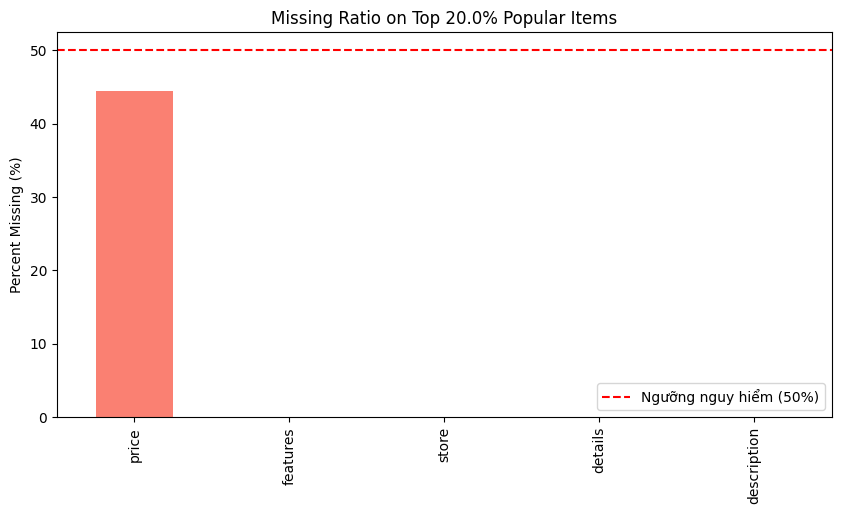

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

# Giả sử df có cột 'item_id' và 'rating_number' (số lượng tương tác)
# Lọc ra top 20% sản phẩm có nhiều tương tác nhất
top_k_percent = 0.2
num_top_items = int(len(df) * top_k_percent)

# Sắp xếp item theo mức độ phổ biến
top_items = df.sort_values(by='rating_number', ascending=False).head(num_top_items)

# Tính lại tỉ lệ missing trên tập Top Items này
features_to_check = ['price', 'features', 'store', 'details', 'description']
missing_on_top = top_items[features_to_check].isnull().mean() * 100

print(f"--- Tỉ lệ thiếu dữ liệu trên Top {top_k_percent*100}% Items phổ biến nhất ---")
print(missing_on_top)

# Vẽ biểu đồ so sánh
plt.figure(figsize=(10, 5))
missing_on_top.plot(kind='bar', color='salmon')
plt.title(f'Missing Ratio on Top {top_k_percent*100}% Popular Items')
plt.ylabel('Percent Missing (%)')
plt.axhline(y=50, color='r', linestyle='--', label='Ngưỡng nguy hiểm (50%)')
plt.legend()
plt.show()

Độ lệch chuẩn giá toàn cục (Global Std): 66.17
Độ lệch chuẩn giá trung bình của từng User (User Std): 12.20


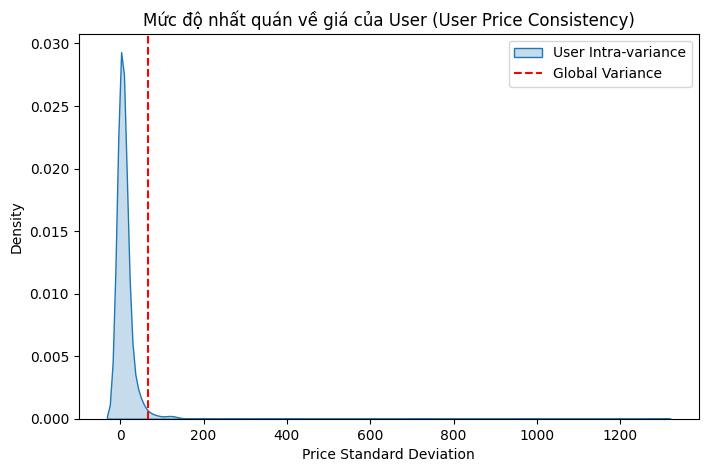

Hệ số tương quan giữa Price và Rating Number: -0.0205


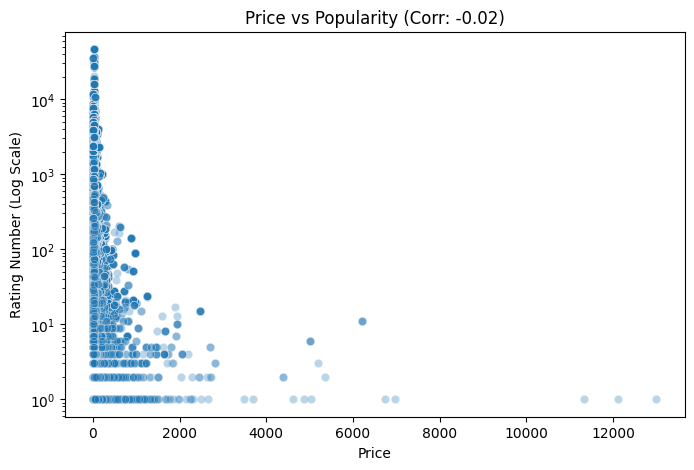

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử df đã có user_id, price.
# Loại bỏ các dòng thiếu price để tính toán thống kê
df_price = df.dropna(subset=['price'])

# 1. Kiểm tra sự phân hóa giá của từng User (User Price Consistency)
# Tính độ lệch chuẩn (std) về giá trong lịch sử mua của từng user (chỉ tính user mua >= 3 món)
user_stats = df_price.groupby('user_id')['price'].agg(['std', 'mean', 'count'])
valid_users = user_stats[user_stats['count'] >= 3]

global_price_std = df_price['price'].std()
avg_user_price_std = valid_users['std'].mean()

print(f"Độ lệch chuẩn giá toàn cục (Global Std): {global_price_std:.2f}")
print(f"Độ lệch chuẩn giá trung bình của từng User (User Std): {avg_user_price_std:.2f}")

# Vẽ biểu đồ so sánh
plt.figure(figsize=(8, 5))
sns.kdeplot(valid_users['std'], fill=True, label='User Intra-variance')
plt.axvline(global_price_std, color='r', linestyle='--', label='Global Variance')
plt.title("User Price Consistency")
plt.xlabel("Price Standard Deviation")
plt.legend()
plt.show()

# 2. Kiểm tra Price vs Popularity (Rating Number)
# Liệu hàng rẻ có nhiều người mua hơn hàng đắt? (Negative Correlation)
correlation = df_price[['price', 'rating_number']].corr().iloc[0, 1]
print(f"Hệ số tương quan giữa Price và Rating Number: {correlation:.4f}")

plt.figure(figsize=(8, 5))
# Dùng log scale cho rating_number vì thường bị lệch
sns.scatterplot(x='price', y='rating_number', data=df_price, alpha=0.3)
plt.yscale('log')
plt.title(f"Price vs Popularity (Corr: {correlation:.2f})")
plt.xlabel("Price")
plt.ylabel("Rating Number (Log Scale)")
plt.show()

In [98]:
df.head()

,product_title,average_rating,rating_number,features,description,price,product_image,store,details,parent_asin,rating,review_title,text,review_image,asin,user_id,timestamp,helpful_vote,verified_purchase
0,yuedge pairs mens moisture control cushioned d...,4.6,16,,,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,givegift,package dimensions x x inches ounces item mode...,B08BHN9PK5,5.0,great sock,sock fits great holds shape comfortable,[],B08BHN9PK5,AFHJMTD3GAMEH722HTM2VEXNOM5Q,1606007321259,0,True
1,doubcq womens palazzo lounge wide leg casual f...,4.1,7,drawstring closure machine wash,,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,doubcq,package dimensions x x inches ounces item mode...,B08R39MRDW,4.0,fit okay,since legs stomach larger areas wish little ro...,[],B08R39MRDW,AH4MZTCIOZHWELLOMO5AV5J2CFUA,1619271363761,1,False
2,doubcq womens palazzo lounge wide leg casual f...,4.1,7,drawstring closure machine wash,,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,doubcq,package dimensions x x inches ounces item mode...,B08R39MRDW,5.0,fits great silky feel skin,pants fit well felt extremely comfortable happy,[],B08R39MRDW,AFKXMG5RTMVMZXBG75SNK5PCMI3A,1631926389500,0,True
3,pastel vivienne honey vanilla girls trapeze dr...,4.3,11,zipper closure hand wash,,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,pastel vivienne,discontinued manufacturer package dimensions x...,B077KJHCJ4,5.0,perfect causal dress,bought dress daughter wear family photos fit p...,[],B077KJHCJ4,AE4RDNNXG3FCUDJZ2PAVSGJRFRGQ,1577068622955,0,True
4,mento streamtail,2.0,1,thermoplastic rubber sole high density premium...,slip womens mento youre ready hit beach thong ...,29.81,[{'thumb': 'https://m.media-amazon.com/images/...,guy harvey,package dimensions x x inches pounds item mode...,B0811M2JG9,2.0,size may true size,size small,[],B0811M2JG9,AE2PFEWEGOFSFZATN6NGXOEHBEIA,1649042471529,0,False


Average User Store Entropy: 0.1136


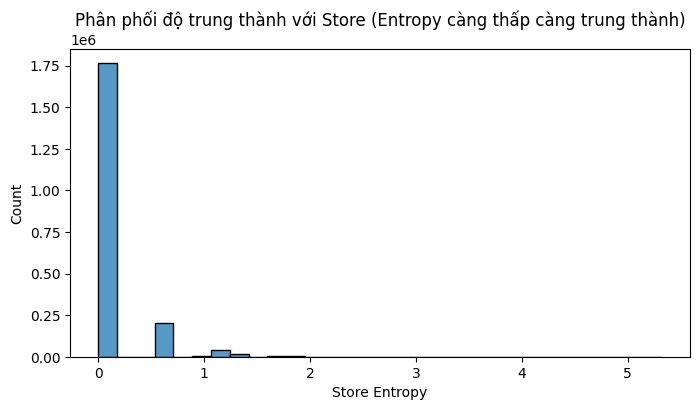

In [99]:
import pandas as pd
import numpy as np

# --- BƯỚC 0: Tối ưu bộ nhớ trước khi tính toán ---
# Chuyển các cột string/object sang category để groupby nhanh hơn gấp nhiều lần
for col in ['user_id', 'store', 'parent_asin', 'item_id']: # Thay 'item_id' bằng 'asin' nếu tên cột của bạn là asin
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].astype('category')

# --- BƯỚC 1: Tính Entropy của Store (Vectorized) ---
# Lọc bỏ các dòng không có store trước
df_store = df.dropna(subset=['store'])

# B1.1: Đếm số lần mỗi user mua tại mỗi store
# Kết quả: user_id | store | count
user_store_counts = df_store.groupby(['user_id', 'store'], observed=True).size().reset_index(name='count')

# B1.2: Tính tổng số lần mua của mỗi user (để làm mẫu số)
user_total_counts = user_store_counts.groupby('user_id', observed=True)['count'].transform('sum')

# B1.3: Tính xác suất P = count / total
user_store_counts['prob'] = user_store_counts['count'] / user_total_counts

# B1.4: Tính thành phần entropy: -P * log(P)
# Cộng thêm 1e-9 để tránh log(0) dù lý thuyết không xảy ra ở đây nhưng an toàn code
user_store_counts['entropy_component'] = -user_store_counts['prob'] * np.log(user_store_counts['prob'] + 1e-9)

# B1.5: Cộng dồn lại theo user để ra Entropy cuối cùng
user_entropy = user_store_counts.groupby('user_id', observed=True)['entropy_component'].sum()

print(f"Average User Store Entropy: {user_entropy.mean():.4f}")

# Optional: Vẽ biểu đồ phân phối Entropy nhanh
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.histplot(user_entropy, bins=30)
plt.title("Phân phối độ trung thành với Store (Entropy càng thấp càng trung thành)")
plt.xlabel("Store Entropy")
plt.show()


Thống kê số lượng Item con trong mỗi Parent ASIN:
count    825869.000000
mean          1.058639
std           1.365883
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         324.000000
Name: asin, dtype: float64


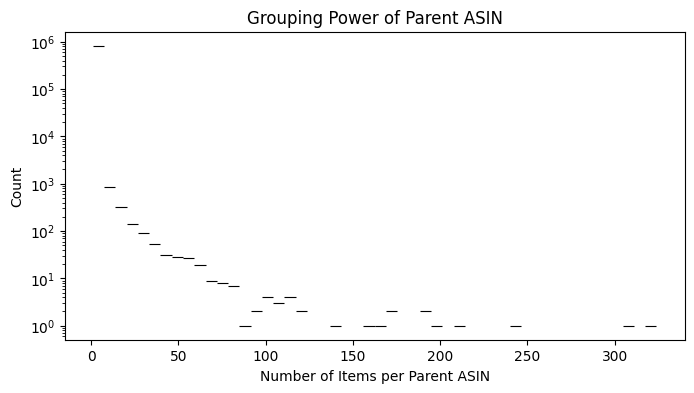

In [100]:
# --- BƯỚC 2: Đánh giá Parent ASIN ---

# Chỉ lấy 2 cột cần thiết để groupby nhẹ hơn
items_per_parent = df[['parent_asin', 'asin']].groupby('parent_asin', observed=True)['asin'].nunique()

# Lọc bỏ những parent_asin bằng 0 (nếu có do dữ liệu bẩn)
items_per_parent = items_per_parent[items_per_parent > 0]

print("\nThống kê số lượng Item con trong mỗi Parent ASIN:")
print(items_per_parent.describe())

# Vẽ biểu đồ (Log scale để nhìn rõ phần đuôi dài)
plt.figure(figsize=(8, 4))
sns.histplot(items_per_parent, bins=50, log_scale=(False, True))
plt.xlabel("Number of Items per Parent ASIN")
plt.title("Grouping Power of Parent ASIN")
plt.show()

Global Price CV (Độ biến động thị trường): 1.0685
Average User Price CV (Độ biến động hành vi user): 0.3181


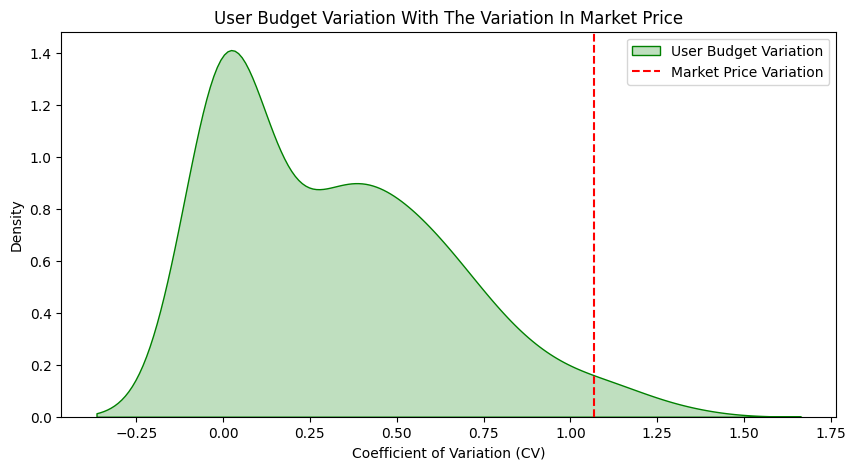

In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chuẩn bị dữ liệu Price (Làm sạch và Log transform)
df_price = df.dropna(subset=['price', 'user_id']).copy()
df_price['price'] = pd.to_numeric(df_price['price'], errors='coerce')
df_price = df_price.dropna(subset=['price'])

# 2. Tính toán độ biến động giá (Coefficient of Variation - CV)
# CV = Std / Mean. CV càng thấp -> Người dùng càng "chung thủy" với một mức giá.

# Chỉ xét các user mua >= 5 món để có ý nghĩa thống kê
user_counts = df_price['user_id'].value_counts()
valid_users = user_counts[user_counts >= 5].index
df_valid = df_price[df_price['user_id'].isin(valid_users)]

# Tính std và mean giá cho từng user
user_stats = df_valid.groupby('user_id')['price'].agg(['std', 'mean'])
user_stats['cv'] = user_stats['std'] / (user_stats['mean'] + 1e-9) # Tránh chia cho 0

# Tính độ biến động giá của TOÀN BỘ sản phẩm (Global)
global_mean = df_valid['price'].mean()
global_std = df_valid['price'].std()
global_cv = global_std / global_mean

print(f"Global Price CV (Độ biến động thị trường): {global_cv:.4f}")
print(f"Average User Price CV (Độ biến động hành vi user): {user_stats['cv'].mean():.4f}")

# Vẽ biểu đồ so sánh
plt.figure(figsize=(10, 5))
sns.kdeplot(user_stats['cv'], fill=True, label='User Budget Variation', color='green')
plt.axvline(global_cv, color='red', linestyle='--', label='Market Price Variation')
plt.title("User Budget Variation With The Variation In Market Price")
plt.xlabel("Coefficient of Variation (CV)")
plt.legend()
plt.show()

--- SO SÁNH HIỆU QUẢ TRÊN TẬP DỮ LIỆU CHUNG ---
Correlation (Price vs Popularity): -0.0248
Correlation (Description Len vs Popularity): -0.0027


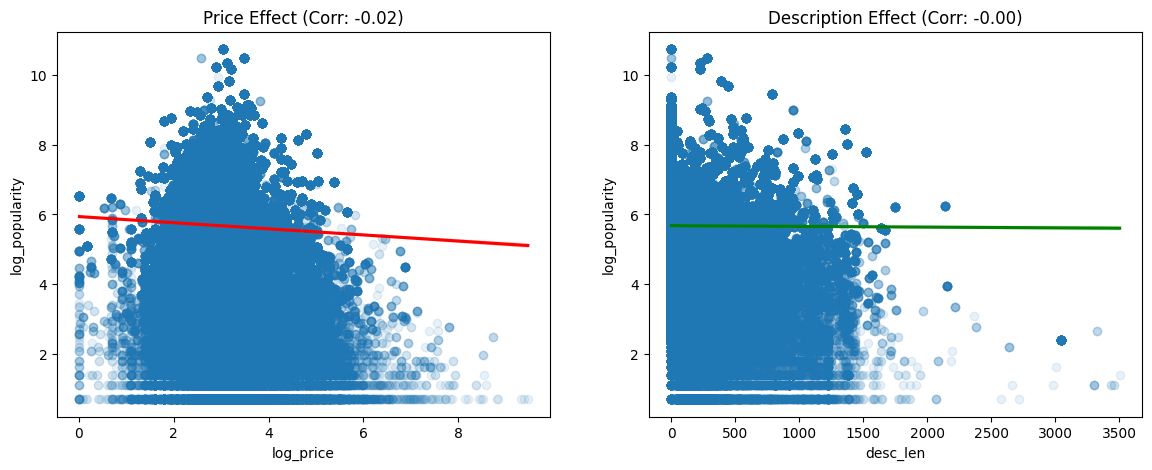

In [102]:
# 1. Lọc tập dữ liệu "Sạch" (Có cả Price và Description)
df_clean = df.dropna(subset=['price', 'description', 'rating_number']).copy()
df_clean['price'] = pd.to_numeric(df_clean['price'], errors='coerce')
df_clean = df_clean.dropna(subset=['price'])

# 2. Feature Engineering
# Price: Log transform (vì giá tiền thường phân phối lệch)
df_clean['log_price'] = np.log1p(df_clean['price'])

# Description: Độ dài (Proxy cho độ chi tiết)
df_clean['desc_len'] = df_clean['description'].astype(str).apply(len)

# Target: Popularity (Log transform)
df_clean['log_popularity'] = np.log1p(df_clean['rating_number'])

# 3. Tính Correlation
corr_price = df_clean['log_price'].corr(df_clean['log_popularity'])
corr_desc = df_clean['desc_len'].corr(df_clean['log_popularity'])

print("--- SO SÁNH HIỆU QUẢ TRÊN TẬP DỮ LIỆU CHUNG ---")
print(f"Correlation (Price vs Popularity): {corr_price:.4f}")
print(f"Correlation (Description Len vs Popularity): {corr_desc:.4f}")

# Vẽ biểu đồ quan hệ
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Price vs Pop
sns.regplot(x='log_price', y='log_popularity', data=df_clean, ax=ax[0], 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})
ax[0].set_title(f'Price Effect (Corr: {corr_price:.2f})')

# Desc vs Pop
sns.regplot(x='desc_len', y='log_popularity', data=df_clean, ax=ax[1], 
            scatter_kws={'alpha':0.1}, line_kws={'color':'green'})
ax[1].set_title(f'Description Effect (Corr: {corr_desc:.2f})')

plt.show()

In [103]:
# Lọc các item có giá
items_with_price = df[df['price'].notna()]

# Tổng số interaction (hoặc rating_number) của toàn bộ dataset
total_interactions = df['rating_number'].sum() # Hoặc len(df) nếu là raw interaction log

# Tổng số interaction được "phủ" bởi các item có giá
covered_interactions = items_with_price['rating_number'].sum()

coverage_ratio = (covered_interactions / total_interactions) * 100

print(f"Tỉ lệ Item có giá: {(1 - 0.8265):.2%}")
print(f"Tỉ lệ Tương tác được phủ bởi Price: {coverage_ratio:.2f}%")

Tỉ lệ Item có giá: 17.35%
Tỉ lệ Tương tác được phủ bởi Price: 91.35%


Tổng số Store: 85788
Trung bình item/store: 29.15
Top 10% store chiếm bao nhiêu % tổng item? 77.32%


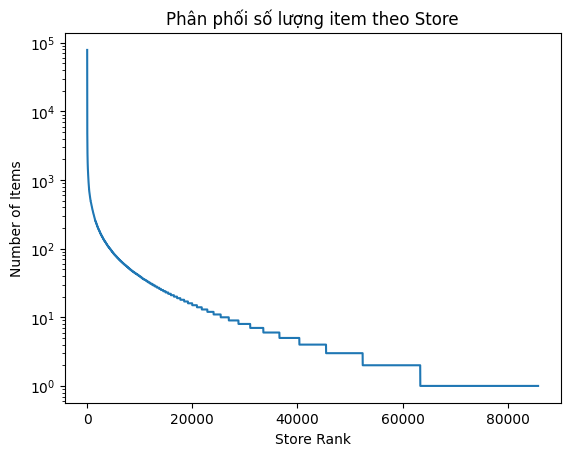

In [104]:
store_counts = df['store'].value_counts()
num_items = len(df)
num_stores = len(store_counts)

print(f"Tổng số Store: {num_stores}")
print(f"Trung bình item/store: {num_items / num_stores:.2f}")
print(f"Top 10% store chiếm bao nhiêu % tổng item? {(store_counts.head(int(num_stores*0.1)).sum() / num_items)*100:.2f}%")

# Vẽ đuôi dài
plt.plot(store_counts.values)
plt.title("Phân phối số lượng item theo Store")
plt.xlabel("Store Rank")
plt.ylabel("Number of Items")
plt.yscale('log')
plt.show()

In [105]:
# Giả sử df là dataframe gốc của bạn (hoặc tập 400k dòng)

# 1. Kiểm tra tỷ lệ trùng lặp của Image
unique_items = df['asin'].nunique()
unique_images = df['product_image'].nunique()
unique_titles = df['product_title'].nunique()

print(f"Total Unique Items (ASIN): {unique_items}")
print(f"Total Unique Images: {unique_images}")
print(f"Total Unique Titles: {unique_titles}")

# Tính tỷ lệ "Collision" (Va chạm)
image_collision_rate = 1 - (unique_images / unique_items)
title_collision_rate = 1 - (unique_titles / unique_items)

print(f"Image Collision Rate: {image_collision_rate:.2%}") # Càng cao càng tệ (nhiều item dùng chung ảnh)
print(f"Title Collision Rate: {title_collision_rate:.2%}")

# 2. Xem cụ thể: Top những image/title được share nhiều nhất
top_shared_images = df.groupby('product_image')['asin'].nunique().sort_values(ascending=False).head(5)
print("\nTop images shared by multiple items:")
print(top_shared_images)
# Bạn sẽ thấy có những image được dùng cho hàng chục/trăm item khác nhau.

Total Unique Items (ASIN): 874297
Total Unique Images: 674047
Total Unique Titles: 719658
Image Collision Rate: 22.90%
Title Collision Rate: 17.69%

Top images shared by multiple items:
product_image
[{'thumb': 'https://m.media-amazon.com/images/I/01RmK+J4pJL._AC_SR38,50_.gif', 'large': 'https://m.media-amazon.com/images/I/01RmK+J4pJL._AC_.gif', 'variant': 'MAIN', 'hi_res': None}]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analyze_price_distribution(df, col_name='price'):
    price = df[col_name]
    
    # --- A. Các chỉ số thống kê ---
    mean_val = price.mean()
    median_val = price.median()
    skewness = price.skew()
    min_val = price.min()
    max_val = price.max()
    
    # Phân vị (Quantiles) để xem sự tập trung dữ liệu
    q25 = price.quantile(0.25)
    q75 = price.quantile(0.75)
    q95 = price.quantile(0.95) # Top 5% đắt nhất bắt đầu từ giá nào

    print(f"=== KẾT QUẢ PHÂN TÍCH CỘT '{col_name}' ===")
    print(f"1. Giá thấp nhất (Min): {min_val}")
    print(f"2. Giá cao nhất (Max): {max_val}")
    print(f"3. Trung bình (Mean): {mean_val:.2f}")
    print(f"4. Trung vị (Median): {median_val:.2f}")
    print(f"5. Độ lệch (Skewness): {skewness:.4f}")
    print(f"6. 95% sản phẩm có giá thấp hơn: {q95:.2f}")
    print("-" * 30)

    # --- B. Trả lời câu hỏi của bạn ---
    if skewness > 1:
        print("=> KẾT LUẬN: Phân phối LỆCH PHẢI (Right Skewed).")
        print("   Nghĩa là: RẤT NHIỀU đồ giá rẻ/trung bình, và RẤT ÍT đồ cực đắt.")
    elif skewness < -1:
        print("=> KẾT LUẬN: Phân phối LỆCH TRÁI (Left Skewed).")
        print("   Nghĩa là: Chủ yếu là đồ đắt tiền, ít đồ rẻ.")
    else:
        print("=> KẾT LUẬN: Phân phối khá cân bằng.")

    if mean_val > median_val:
        print("   (Dấu hiệu thêm: Mean > Median chứng tỏ có những món đồ rất đắt kéo giá trung bình lên).")

    # --- C. Vẽ biểu đồ trực quan ---
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    # Biểu đồ 1: Histogram (Phân phối chung)
    sns.histplot(price, kde=True, bins=50, color='teal', ax=ax[0])
    ax[0].set_title('Biểu đồ phân phối giá (Histogram)')
    ax[0].axvline(mean_val, color='red', linestyle='--', label='Mean')
    ax[0].axvline(median_val, color='yellow', linestyle='-', label='Median')
    ax[0].legend()

    # Biểu đồ 2: Boxplot (Để soi Outlier - đồ cực đắt)
    sns.boxplot(x=price, color='orange', ax=ax[1])
    ax[1].set_title('Biểu đồ hộp (Boxplot) - Soi giá trị ngoại lai')

    plt.show()

# Giả sử df là dataframe của bạn
# analyze_price_distribution(df, 'price')

In [107]:
!pip install wordcloud matplotlib pandas


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Processing text data...
Generating Word Cloud...


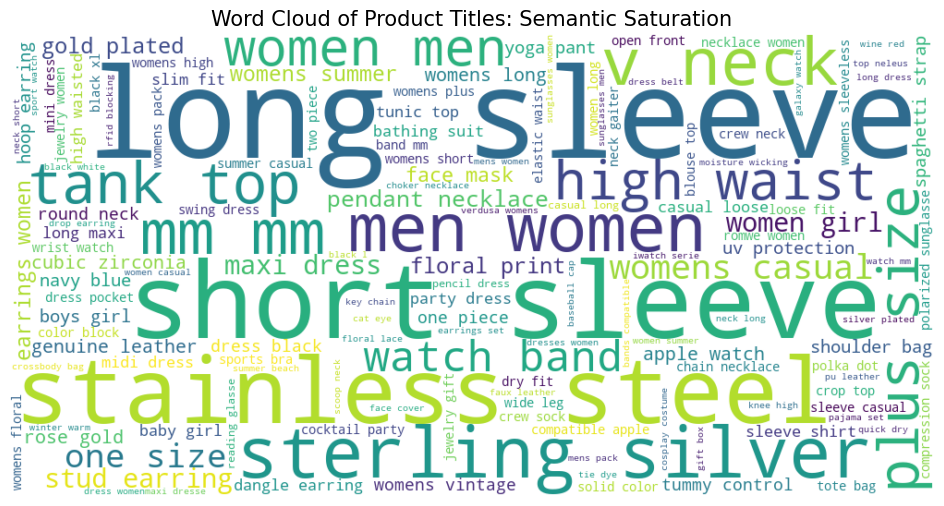


Calculating keyword frequencies...

--- TOP 10 MOST FREQUENT KEYWORDS IN 2500939 PRODUCTS ---
Word            | Count      | % of Titles
---------------------------------------------
womens          | 668070     | 26.71%
women           | 529835     | 21.19%
black           | 385191     | 15.40%
dress           | 317016     | 12.68%
sleeve          | 292481     | 11.69%
long            | 254493     | 10.18%
mens            | 227933     | 9.11%
casual          | 213260     | 8.53%
size            | 186275     | 7.45%
mm              | 178615     | 7.14%

INTERPRETATION:
If top words (like 'socks') appear in a high % of titles,
it proves that text features lack discriminative power for this dataset.


In [108]:
# ==========================================
# STEP 1: Installation (Run once if needed)
# ==========================================
# !pip install wordcloud matplotlib pandas

# ==========================================
# STEP 2: Import Libraries and Process Data
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import re

# NOTE: Ensure your DataFrame 'df' is loaded before running this.
# Example: df = pd.read_csv("your_data.csv")

# 1. Prepare text data
# Convert column to string, drop Null values, convert to lowercase
print("Processing text data...")
text_data = df['product_title'].dropna().astype(str).str.lower().tolist()
text_combined = " ".join(text_data)

# ==========================================
# STEP 3: Generate Word Cloud (Proving Saturation)
# ==========================================

# Define Stopwords (words to exclude)
custom_stopwords = set(STOPWORDS)

# NOTE: To prove that titles are generic, you might want to LEAVE generic words in.
# If you want to remove them to see deeper features, uncomment the line below:
# custom_stopwords.update(['socks', 'sock', 'pair', 'pack', 'pairs', 'men', 'women'])

# Initialize WordCloud
print("Generating Word Cloud...")
wordcloud = WordCloud(width=1000, height=500, 
                      background_color='white', 
                      stopwords=custom_stopwords,
                      min_font_size=10).generate(text_combined)

# Plotting
plt.figure(figsize=(12, 6))

# --- BUG FIX APPLIED HERE ---
# We use .to_image() to convert the WordCloud object to a PIL Image.
# This avoids the "TypeError: asarray() got an unexpected keyword argument 'copy'"
# caused by version conflicts between matplotlib and numpy.
plt.imshow(wordcloud.to_image(), interpolation="bilinear")

plt.axis("off")
plt.title("Word Cloud of Product Titles: Semantic Saturation", fontsize=15)
plt.show()

# ==========================================
# STEP 4: Statistical Analysis (For your Report)
# ==========================================
print("\nCalculating keyword frequencies...")
words = re.findall(r'\w+', text_combined)
word_counts = Counter(words)
total_titles = len(df)

print(f"\n--- TOP 10 MOST FREQUENT KEYWORDS IN {total_titles} PRODUCTS ---")
print(f"{'Word':<15} | {'Count':<10} | {'% of Titles'}")
print("-" * 45)

for word, count in word_counts.most_common(10):
    # Calculate the rough percentage of titles containing this word
    ratio = (count / total_titles) * 100 
    print(f"{word:<15} | {count:<10} | {ratio:.2f}%")

print("\nINTERPRETATION:")
print("If top words (like 'socks') appear in a high % of titles,")
print("it proves that text features lack discriminative power for this dataset.")

=== KẾT QUẢ PHÂN TÍCH CỘT 'price' ===
1. Giá thấp nhất (Min): 0.01
2. Giá cao nhất (Max): 13000.0
3. Trung bình (Mean): 27.37
4. Trung vị (Median): 18.95
5. Độ lệch (Skewness): 71.1227
6. 95% sản phẩm có giá thấp hơn: 71.95
------------------------------
=> KẾT LUẬN: Phân phối LỆCH PHẢI (Right Skewed).
   Nghĩa là: RẤT NHIỀU đồ giá rẻ/trung bình, và RẤT ÍT đồ cực đắt.
   (Dấu hiệu thêm: Mean > Median chứng tỏ có những món đồ rất đắt kéo giá trung bình lên).


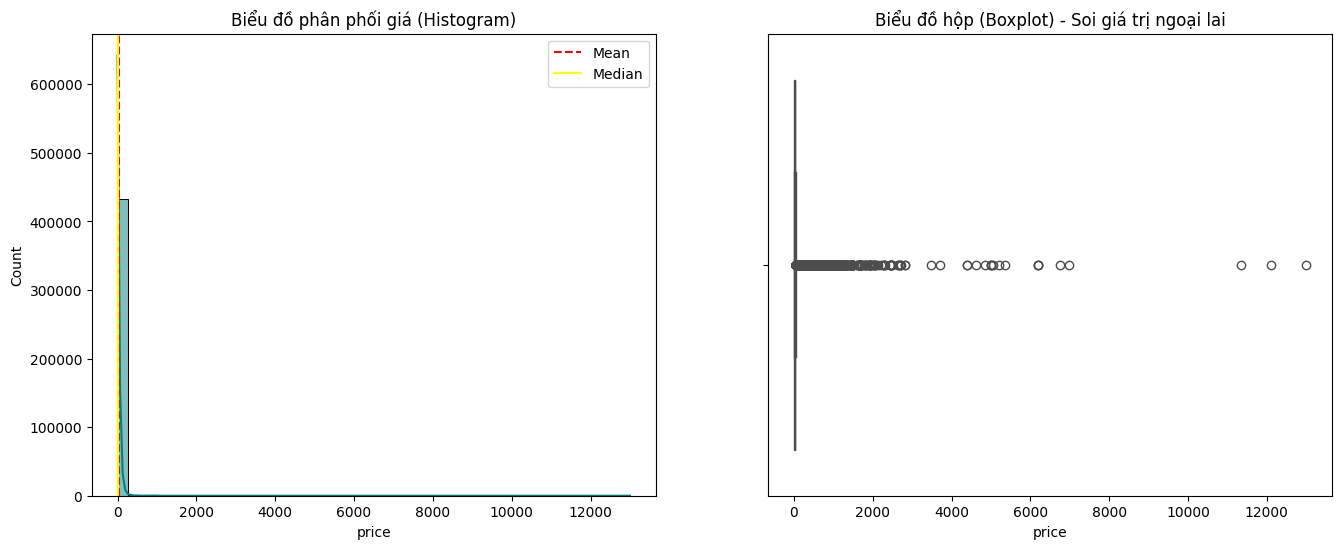

In [109]:
analyze_price_distribution(df,'price')

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2500939 entries, 0 to 2500938
Data columns (total 19 columns):
 #   Column             Dtype   
---  ------             -----   
 0   product_title      object  
 1   average_rating     float64 
 2   rating_number      int64   
 3   features           object  
 4   description        object  
 5   price              float64 
 6   product_image      object  
 7   store              category
 8   details            object  
 9   parent_asin        category
 10  rating             float64 
 11  review_title       object  
 12  text               object  
 13  review_image       object  
 14  asin               object  
 15  user_id            category
 16  timestamp          int64   
 17  helpful_vote       int64   
 18  verified_purchase  bool    
dtypes: bool(1), category(3), float64(3), int64(3), object(9)
memory usage: 457.5+ MB


In [111]:
num_unique_ui = df.drop_duplicates(
    subset=["user_id", "asin"]
).shape[0]

print(num_unique_ui)

2475694


In [112]:
print("Users:", df["user_id"].nunique())
print("Items:", df["asin"].nunique())
print("Unique (user,item):",
      df.drop_duplicates(subset=["user_id", "asin"]).shape[0])

Users: 2035490
Items: 874297
Unique (user,item): 2475694


In [113]:
import pandas as pd

# df is your original dataframe

# 1. Original dataframe (no filtering)
df1 = df.copy()

# 2. Clean dataframe: remove rows with null price
df2 = df[df['price'].notna()].copy()

# Export to CSV
df1.to_csv("org_data.csv", index=False)
df2.to_csv("clean_data.csv", index=False)


In [114]:
def is_missing_value(x):
    # Case 1: NaN / None
    if pd.isna(x):
        return True

    # Case 2: string cases
    if isinstance(x, str):
        value = x.strip().lower()

        # empty / common null strings
        if value in {"", "none", "nan", "null"}:
            return True

        # empty list / dict in string form
        if value in {"[]", "{}", "[ ]", "{ }"}:
            return True

        # string zero (useful for price-like columns)
        if value == "0":
            return True

    # Case 3: actual empty list / dict
    if isinstance(x, (list, dict)) and len(x) == 0:
        return True

    # Case 4: numeric zero (again, mainly for price)
    if x == 0 or x == 0.0:
        return True

    return False


In [115]:
missing_stats_df = (
    df2
    .apply(lambda column: column.map(is_missing_value).mean())
    .to_frame(name="missing_ratio")
    .sort_values("missing_ratio", ascending=False)
)


In [116]:
missing_stats_df["missing_percentage"] = missing_stats_df["missing_ratio"] * 100


In [117]:
print(missing_stats_df)


                   missing_ratio  missing_percentage
review_image            0.934646           93.464638
helpful_vote            0.793945           79.394487
description             0.582716           58.271623
features                0.096206            9.620563
verified_purchase       0.046460            4.646016
details                 0.015615            1.561506
store                   0.010080            1.007959
review_title            0.006015            0.601501
text                    0.004152            0.415218
product_title           0.000032            0.003228
rating                  0.000000            0.000000
average_rating          0.000000            0.000000
product_image           0.000000            0.000000
price                   0.000000            0.000000
asin                    0.000000            0.000000
user_id                 0.000000            0.000000
timestamp               0.000000            0.000000
rating_number           0.000000            0.